In [1]:
import spectral_util
import spectral_util.spec_io as spec_io
import spectral_util.mosaic as mosaic

import os
from glob import glob
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt
from osgeo import osr
import pyproj

%matplotlib widget

In [10]:
def find_subgrid_locations_analytical(ul_x, ul_y, x_res, y_res, x_subgrid, y_subgrid, ncols_out, nrows_out):
    """
    Analytical appraoch to finding the locations of the subgrid elements within the main grid, given a regular grid, pre-orthorectified tiles, and the same crs / resolution across subgrids and the main grid.

    Args:
        ul_x (float): The x coordinate of the upper left corner of the main grid.
        ul_y (float): The y coordinate of the upper left corner of the main grid.
        x_resolution (float): X resolution of the output mosaic.
        y_resolution (float): Y resolution of the output mosaic.
        x_subgrid (np.array): longitude subgrid - loc[...,0]
        y_subgrid (np.array): latitude subgrid - loc[...,1]
        ncols_out (float): ncols in the main grid
        nrows_out (float): nrows in the main grid

    Returns:
        np.ndarray: The (row, col) indices of the subgrid elements in the main grid.
    """
    col0 = np.rint((x_subgrid - ul_x) / x_res)
    row0 = np.rint((ul_y - y_subgrid) / y_res*-1) # need y-resolution positive here

    valid = (col0 >= 0) & (col0 < ncols_out) & (row0 >= 0) & (row0 < nrows_out)

    sub_glt_insert_idx = np.zeros((*col0.shape, 2))
    # figure out whether to add 1 or not... ?
    sub_glt_insert_idx[..., 0][valid] = row0[valid]
    sub_glt_insert_idx[..., 1][valid] = col0[valid]   

    # Ensure consistent nodata: if either is 0, both are 0
    bad = (sub_glt_insert_idx[..., 0] == 0) | (sub_glt_insert_idx[..., 1] == 0)
    sub_glt_insert_idx[bad, :] = 0

    sub_glt_insert_idx = sub_glt_insert_idx.astype(np.int32)
    
    if np.sum(sub_glt_insert_idx) == 0:
        sub_glt_insert_idx = None
    
    return sub_glt_insert_idx, valid


In [15]:
ul_x=ul_lr[0]
ul_y=ul_lr[1]
x_res=x_resolution
y_res=x_resolution*1
x_subgrid=loc[...,0]
y_subgrid=loc[...,1]
ncols_out=glt.shape[1]
nrows_out=glt.shape[0]

In [21]:
x_subgrid.shape

(3562, 1631)

In [19]:
sub_glt = np.indices((loc.shape[0], loc.shape[1]), dtype=np.int32).transpose(1, 2, 0)
sub_glt.shape

(3562, 1631, 2)

In [20]:
sub_glt

array([[[   0,    0],
        [   0,    1],
        [   0,    2],
        ...,
        [   0, 1628],
        [   0, 1629],
        [   0, 1630]],

       [[   1,    0],
        [   1,    1],
        [   1,    2],
        ...,
        [   1, 1628],
        [   1, 1629],
        [   1, 1630]],

       [[   2,    0],
        [   2,    1],
        [   2,    2],
        ...,
        [   2, 1628],
        [   2, 1629],
        [   2, 1630]],

       ...,

       [[3559,    0],
        [3559,    1],
        [3559,    2],
        ...,
        [3559, 1628],
        [3559, 1629],
        [3559, 1630]],

       [[3560,    0],
        [3560,    1],
        [3560,    2],
        ...,
        [3560, 1628],
        [3560, 1629],
        [3560, 1630]],

       [[3561,    0],
        [3561,    1],
        [3561,    2],
        ...,
        [3561, 1628],
        [3561, 1629],
        [3561, 1630]]], dtype=int32)

In [2]:
input_file_list = all_obs_files="/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt"
mosaic_glt_out="/store/carroll/col/data/2018/mosaic/neon_2018_mosaic_glt_analytical.tif"
log_file="/home/carroll/logs/mosaic_2018_analytical.log"
x_resolution = 1
y_resolution = None
output_epsg = 32613
criteria_band = 5
criteria_mode = 'min'
ignore_file_list = None
deprioritize_file_list = None
target_extent_ul_lr = None

In [3]:
if y_resolution is not None and y_resolution > 0:
    logging.warning("y_resolution is set to a positive value, which is not common.  Unless this is being done very intentionally, stop, and make y negative.")
elif y_resolution is None:
    y_resolution = -1 * x_resolution

if input_file_list.endswith(".nc"):
    input_files = [input_file_list]
else:
    input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]

ignore_files = []
if ignore_file_list is not None:
    ignore_files = [x.strip() for x in open(ignore_file_list, 'r').readlines()]

deprioritize_files = []
if deprioritize_file_list is not None:
    deprioritize_files = [x.strip() for x in open(deprioritize_file_list, 'r').readlines()]

gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

if target_extent_ul_lr:
    ul_lr = target_extent_ul_lr # in output epsg projection
else:
    # Always gets this in 4326
    ul_lr = mosaic.get_ul_lr_from_files(input_files, get_resolution=False)
    # convert to output epsg
    ul = proj(ul_lr[0], ul_lr[1])
    lr = proj(ul_lr[2], ul_lr[3])
    ul_lr = [ul[0], ul[1], lr[0], lr[1]]

if str(output_epsg)[0] == "4" and x_resolution > 1:
    raise ValueError(f"x_resolution is {x_resolution} (indicating meters), and EPSG is {output_epsg}.  Smells like lat/lon and UTM mismatch.  Terminating.")

trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
criteria = np.zeros((glt.shape[0], glt.shape[1]), dtype=np.float32)
criteria[...] = np.nan

glt.shape, criteria.shape

((26889, 21161, 3), (26889, 21161))

In [4]:
_file = 0
file = input_files[0]
_file, file

(0,
 '/store/carroll/col/data/2018/raw/L1/2018061214/NIS01_20180612_154959_rdn_obs_ort')

In [5]:
local_meta, obs = spec_io.load_data(file.strip(), lazy=True, load_glt=False, load_loc=True)
if file in deprioritize_files:
    if criteria_mode == "min":
        obs[...,criteria_band] = obs[...,criteria_band] + 100
    elif criteria_mode == "max":
        obs[...,criteria_band] = obs[...,criteria_band] - 100        

if '2018' in file:
    loc_file = file.replace('obs_ort','ort_igm_ort')+'.hdr' # for NEON-formatted envi files
elif '2025' in file:
    loc_file = file.replace('OBS_Data','IGM_Data')+'.hdr'
loc = envi.open(loc_file).open_memmap()[...,0:2]

In [6]:
sub_glt_insert_idx = mosaic.find_subgrid_locations_analytical(
    ul_lr[0],
    ul_lr[1],
    x_resolution,
    y_resolution,
    loc[...,0],
    loc[...,1],
    glt.shape[1],
    glt.shape[0]
)  

In [8]:
sub_glt_insert_idx.shape, sub_glt_insert_idx.dtype

((3562, 1631, 2), dtype('int32'))

In [9]:
if criteria_band is not None:
    raw_ob = obs[:,:,criteria_band]
    existing_crit = criteria[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1]]
    valid =  np.logical_and(valid, raw_ob != local_meta.nodata_value)

    if criteria_mode == "min":
        crit_mask = np.logical_and(raw_ob < existing_crit, valid)
    elif criteria_mode == "max":
        crit_mask = np.logical_and(raw_ob > existing_crit, valid)
    else:
        raise ValueError(f"Invalid criteria_mode: {criteria_mode}")

                
    # In any mode, if there were no previous data, that counts too
    crit_mask = np.logical_or(crit_mask, np.logical_and(valid, np.isnan(existing_crit)))
    
    # only assign criteria band if used
    criteria[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1]] = raw_ob[crit_mask]
else:
    crit_mask = valid

NameError: name 'valid' is not defined

In [23]:
criteria.shape

(26889, 21161)

In [25]:
sub_glt_insert_idx.dtype

dtype('float64')

In [27]:
np.max(sub_glt_insert_idx)

21160.0

In [11]:
# test build_obs_nc function

input_file_list = '/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt'
ignore_file_list = None
deprioritize_file_list = None
x_resolution = 1
y_resolution = x_resolution*-1
target_extent_ul_lr = None
output_epsg = 32613
criteria_band = 5
criteria_mode = 'min'

In [12]:
input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]
ignore_files = []
deprioritize_files = []

gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

In [13]:
if target_extent_ul_lr:
    ul_lr = target_extent_ul_lr # in output epsg projection
else:
    # Always gets this in 4326
    ul_lr = mosaic.get_ul_lr_from_files(input_files, get_resolution=False)
    # convert to output epsg
    ul = proj(ul_lr[0], ul_lr[1])
    lr = proj(ul_lr[2], ul_lr[3])
    ul_lr = [ul[0], ul[1], lr[0], lr[1]]
print(ul_lr)

trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
criteria = np.zeros((glt.shape[0], glt.shape[1]), dtype=np.float32)
criteria[...] = np.nan

[316127.5833512874, 4324418.625222021, 337288.4827872183, 4297530.547926542]


In [14]:
_file = 0
file = input_files[_file]

if '2018' in file:
    loc_file = file.replace('obs_ort','ort_igm_ort')+'.hdr' # for NEON-formatted envi files
elif '2025' in file:
    loc_file = file.replace('OBS_Data','IGM_Data')+'.hdr'
loc = envi.open(loc_file).open_memmap()[...,0:2]
loc.shape

(3562, 1631, 2)

In [7]:
sub_glt_insert_idx = mosaic.find_subgrid_locations_analytical(
    ul_x=ul_lr[0], ul_y=ul_lr[1], 
    x_res=x_resolution, y_res=y_resolution,
    x_subgrid=loc[...,0],
    y_subgrid=loc[...,1],
    ncols_out=glt.shape[1],
    nrows_out=glt.shape[0])

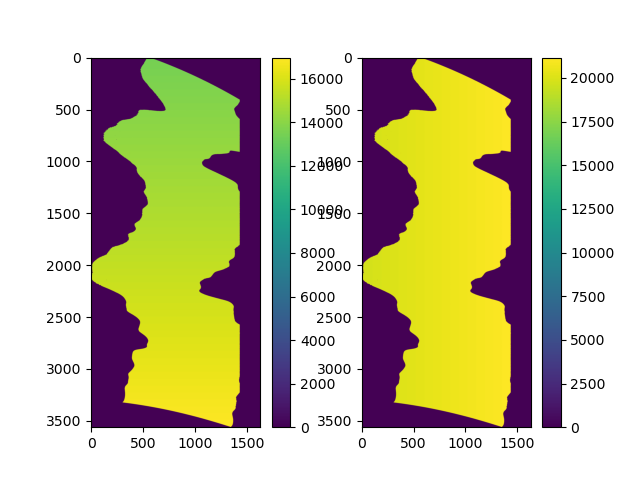

In [21]:
fig, axs = plt.subplots(ncols=2)

p0 = axs[0].imshow(sub_glt_insert_idx[...,0])
p1 = axs[1].imshow(sub_glt_insert_idx[...,1])

fig.colorbar(p0, ax=axs[0])
fig.colorbar(p1, ax=axs[1])

plt.show()

In [233]:
def find_subgrid_locations_analytical(ul_x, ul_y, x_res, y_res, x_subgrid, y_subgrid, ncols_out, nrows_out):
    col0 = np.rint((x_subgrid - ul_x) / x_res)
    row0 = np.rint((ul_y - y_subgrid) / y_res*-1) # need y-resolution positive here

    valid = (col0 >= 0) & (col0 < ncols_out) & (row0 >= 0) & (row0 < nrows_out)

    sub_glt_insert_idx = np.zeros((*col0.shape, 2))
    # figure out whether to add 1 or not... ?
    sub_glt_insert_idx[..., 0][valid] = row0[valid]
    sub_glt_insert_idx[..., 1][valid] = col0[valid]   

    # Ensure consistent nodata: if either is 0, both are 0
    bad = (sub_glt_insert_idx[..., 0] == 0) | (sub_glt_insert_idx[..., 1] == 0)
    sub_glt_insert_idx[bad, :] = 0

    if np.sum(sub_glt_insert_idx) == 0
        sub_glt_insert_idx = None
    
    return sub_glt_insert_idx

In [9]:
np.sum(sub_glt_insert_idx)

116215228618.0

In [234]:
sub_glt_insert_idx = find_subgrid_locations_analytical(ul_x, ul_y, x_res, y_res, x_subgrid, y_subgrid, ncols_out, nrows_out)

In [235]:
sub_glt_insert_idx.shape

(3562, 1631, 2)

In [ ]:
    if criteria_band is not None:
        raw_ob = obs[:,:,criteria_band]
        existing_crit = criteria[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1]]
        valid =  np.logical_and(valid, raw_ob != local_meta.nodata_value)
        crit_mask = np.logical_and(raw_ob < existing_crit, valid)
        # In any mode, if there were no previous data, that counts too
        crit_mask = np.logical_or(crit_mask, np.logical_and(valid, np.isnan(existing_crit)))
        # only assign criteria band if used
        criteria[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1]] = raw_ob[crit_mask]
    else:

In [2]:
# test build_obs_nc function

input_file_list = '/store/carroll/col/data/2018/mosaic/file_lists/top_priority_isofit_obs.txt'
ignore_file_list = None
deprioritize_file_list = None
x_resolution = 1
y_resolution = x_resolution*-1
target_extent_ul_lr = None
output_epsg = 32613
criteria_band = 5
criteria_mode = 'min'

In [3]:
input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]
ignore_files = []
deprioritize_files = []

gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

In [152]:
if target_extent_ul_lr:
    ul_lr = target_extent_ul_lr # in output epsg projection
else:
    # Always gets this in 4326
    ul_lr = mosaic.get_ul_lr_from_files(input_files, get_resolution=False)
    # convert to output epsg
    ul = proj(ul_lr[0], ul_lr[1])
    lr = proj(ul_lr[2], ul_lr[3])
    ul_lr = [ul[0], ul[1], lr[0], lr[1]]
print(ul_lr)

trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
criteria = np.zeros((glt.shape[0], glt.shape[1]), dtype=np.float32)
criteria[...] = np.nan

y_grid_steps = np.arange(ul_lr[1], ul_lr[3] - trans[5]*0.01,trans[5])
x_grid_steps = np.arange(ul_lr[0], ul_lr[2] - trans[1]*0.01,trans[1])
y_grid, x_grid = np.meshgrid(y_grid_steps, 
                             x_grid_steps,
                             indexing='ij')

glt.shape, criteria.shape

[316127.5833512874, 4324418.625222021, 337288.4827872183, 4297530.547926542]


((26889, 21161, 3), (26889, 21161))

In [5]:
_file = 0
file = input_files[_file]
_file, file

(0,
 '/store/carroll/col/data/2018/raw/L1/2018061214/NIS01_20180612_154959_rdn_obs_ort')

In [154]:
local_meta, obs = spec_io.load_data(file.strip(), lazy=True, load_glt=False, load_loc=True)
obs.shape

(3562, 1631, 11)

In [155]:
if '2018' in file:
    loc_file = file.replace('obs_ort','ort_igm_ort')+'.hdr' # for NEON-formatted envi files
elif '2025' in file:
    loc_file = file.replace('OBS_Data','IGM_Data')+'.hdr'
loc = envi.open(loc_file).open_memmap()[...,0:2]
loc.shape

(3562, 1631, 2)

In [ ]:
# old version
# sub_glt, sub_glt_insert_idx = mosaic.find_subgrid_locations(y_grid, x_grid, loc[...,1], loc[...,0], n_workers=1, max_distance=max_distance)

In [156]:
ul_x = ul_lr[0]
ul_y = ul_lr[1]
x_res = x_resolution
y_res = y_resolution
x_subgrid = loc[...,0]
y_subgrid = loc[...,1]
ncols_out = glt.shape[1]
nrows_out = glt.shape[0]
max_distance = None

x_subgrid.shape, y_subgrid.shape, ncols_out, nrows_out

((3562, 1631), (3562, 1631), 21161, 26889)

In [157]:
col0 = np.rint((x_subgrid - ul_x) / x_res).astype(np.int32)
row0 = np.rint((ul_y - y_subgrid) / y_res*-1).astype(np.int32) # need y-resolution positive here

col0.shape, row0.shape

((3562, 1631), (3562, 1631))

In [158]:
np.min(col0), np.max(col0), np.min(row0), np.max(row0)

(-326127, 21364, 13412, 4334418)

In [159]:
ncols_out, nrows_out

(21161, 26889)

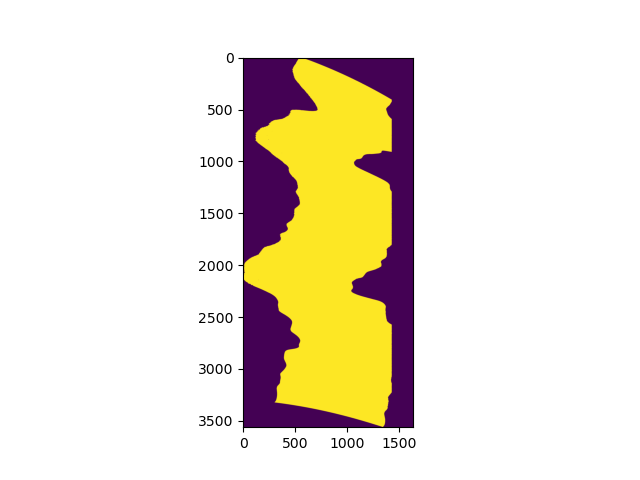

In [160]:
# Bounds mask
valid = (col0 >= 0) & (col0 < ncols_out) & (row0 >= 0) & (row0 < nrows_out)
valid.shape

fig = plt.figure()
plt.imshow(valid)
plt.show()

In [161]:
# Initialize outputs
glt_xy = np.zeros((*col0.shape, 2), dtype=np.int32) # what is this supposed to be?
insert_idx = np.zeros((*col0.shape, 2), dtype=np.int32) # this is the row, col idx in the out glt grid for each pixel in the subgrid
glt_xy.shape, insert_idx.shape

((3562, 1631, 2), (3562, 1631, 2))

In [163]:
# figure out whether to add 1 or not... ?
insert_idx[..., 0][valid] = row0[valid]
insert_idx[..., 1][valid] = col0[valid]

In [62]:
glt_xy[..., 0][valid] = col0[valid] + 1
glt_xy[..., 1][valid] = row0[valid] + 1

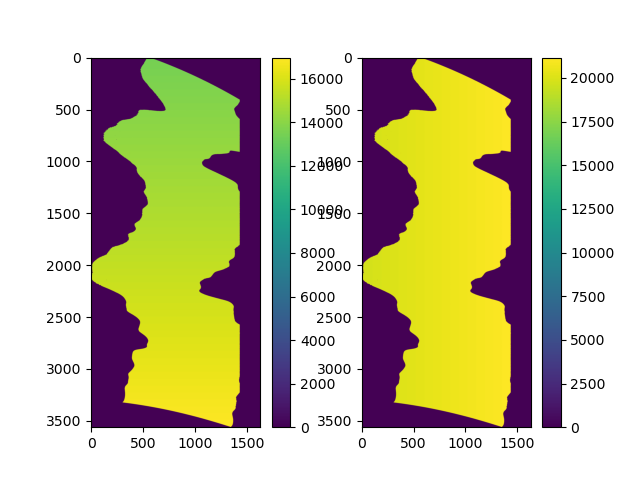

In [236]:
fig, axs = plt.subplots(ncols=2)

p0 = axs[0].imshow(sub_glt_insert_idx[...,0])
p1 = axs[1].imshow(sub_glt_insert_idx[...,1])

fig.colorbar(p0, ax=axs[0])
fig.colorbar(p1, ax=axs[1])

plt.show()

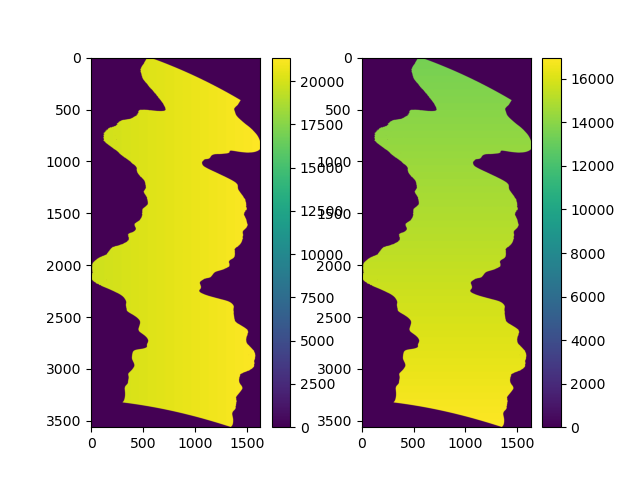

In [64]:
fig, axs = plt.subplots(ncols=2)

p0 = axs[0].imshow(glt_xy[...,0])
p1 = axs[1].imshow(glt_xy[...,1])

fig.colorbar(p0, ax=axs[0])
fig.colorbar(p1, ax=axs[1])

plt.show()

In [231]:
# Ensure consistent nodata: if either is 0, both are 0
bad = (insert_idx[..., 0] == 0) | (insert_idx[..., 1] == 0)
# glt_xy[bad, :] = 0
insert_idx[bad, :] = 0

In [165]:
sub_glt, sub_glt_insert_idx = glt_xy, insert_idx

In [166]:
np.max(sub_glt_insert_idx[...,1]), np.max(sub_glt[...,1])

(21160, 0)

In [50]:
glt.shape

(26889, 21161, 3)

In [ ]:
mosaic.remove_negatives(sub_glt, clean_contiguous=True)

In [167]:
# crit_mask = sub_glt[...,0] != 0  # if criteria_band is None
crit_mask = valid

In [168]:
glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], :2] = sub_glt[crit_mask,:]
glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], 2] = _file + 1

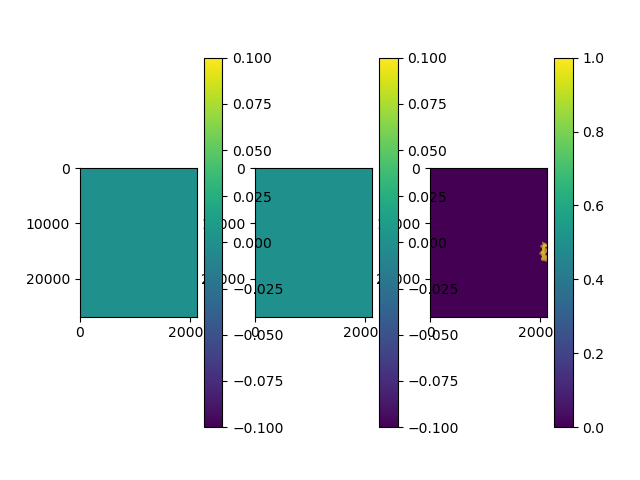

In [169]:
fig, axs = plt.subplots(ncols=3)

p0 = axs[0].imshow(glt[...,0])
fig.colorbar(p0, ax=axs[0])

p1 = axs[1].imshow(glt[...,1])
fig.colorbar(p1, ax=axs[1])

p2 = axs[2].imshow(glt[...,2])
fig.colorbar(p2, ax=axs[2])

plt.show()

In [187]:
del raw_ob

(3562, 1631)


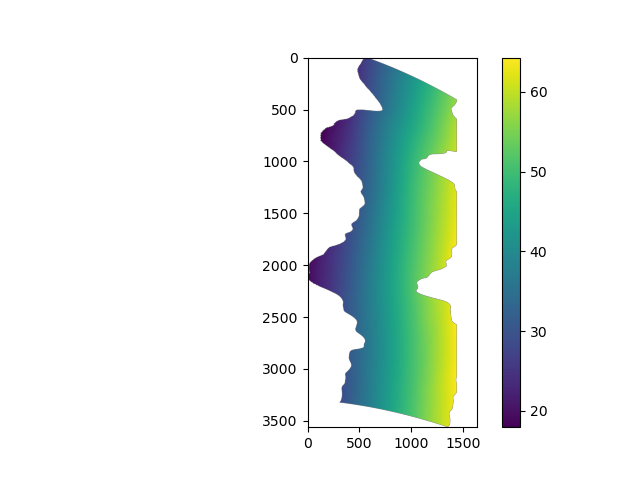

In [203]:
raw_ob = obs[:,:,criteria_band].copy()
raw_ob[~valid] = np.nan
ob = raw_ob
print(raw_ob.shape)

fig = plt.figure()
plt.imshow(raw_ob)
plt.colorbar()
plt.show()

(3562, 1631)


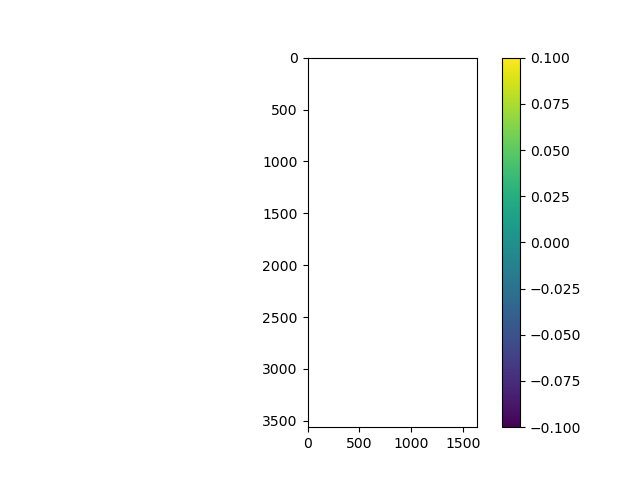

In [193]:
existing_crit = criteria[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1]]
existing_crit.shape
print(existing_crit.shape)

fig = plt.figure()
plt.imshow(existing_crit)
plt.colorbar()
plt.show()

In [185]:
# fig = plt.figure()
# plt.imshow(valid)
# plt.colorbar()
# plt.show()

valid =  np.logical_and(valid, raw_ob != local_meta.nodata_value)

# fig = plt.figure()
# plt.imshow(valid)
# plt.colorbar()
# plt.show()


In [194]:
valid.shape, existing_crit.shape

((3562, 1631), (3562, 1631))

In [209]:
10<np.nan

False

In [206]:
crit_mask = np.logical_and(ob < existing_crit, valid)
print(crit_mask.shape)

fig = plt.figure()
plt.imshow(crit_mask)
plt.show()

TypeError: logical_and() takes from 2 to 3 positional arguments but 1 were given

In [223]:
raw_ob = obs[:,:,criteria_band]
ob = raw_ob[valid]
ob.shape

(3243130,)

In [216]:
tmp = valid[valid]
tmp.shape

(3243130,)

In [224]:
existing_crit = criteria[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1]]
valid =  np.logical_and(valid, raw_ob != local_meta.nodata_value)
valid.shape, existing_crit.shape

((3562, 1631), (3562, 1631))

In [ ]:
crit_mask = np.logical_and(raw_ob < existing_crit, valid)
fig = plt.figure()
plt.imshow(crit_mask)
plt.show()

(3562, 1631)


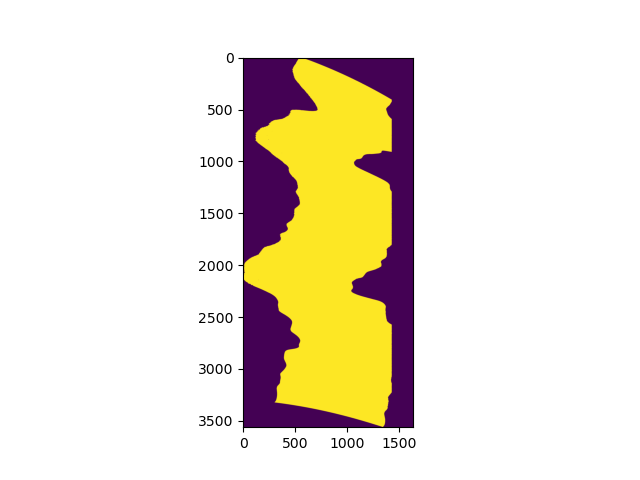

In [228]:
# In any mode, if there were no previous data, that counts too
crit_mask = np.logical_or(crit_mask, np.logical_and(valid, np.isnan(existing_crit)))
print(crit_mask.shape)

fig = plt.figure()
plt.imshow(crit_mask)
plt.show()

In [229]:
# only assign criteria band if used
criteria[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1]] = raw_ob[crit_mask]

In [230]:
glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], :2] = sub_glt[crit_mask,:]
glt[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1], 2] = _file + 1

In [41]:
if criteria_band is not None:
    raw_ob = obs[:,:,criteria_band]
    ob = raw_ob[np.abs(sub_glt[...,1])-1, np.abs(sub_glt[...,0])-1]
    existing_crit = criteria[sub_glt_insert_idx[...,0], sub_glt_insert_idx[...,1]]
    valid =  np.logical_and(sub_glt[...,0] != meta.nodata_value, ob != local_meta.nodata_value)

    if criteria_mode == "min":
        crit_mask = np.logical_and(ob < existing_crit, valid)
    elif criteria_mode == "max":
        crit_mask = np.logical_and(ob > existing_crit, valid)
    else:
        raise ValueError(f"Invalid criteria_mode: {criteria_mode}")
    
    # In any mode, if there were no previous data, that counts too
    crit_mask = np.logical_or(crit_mask, np.logical_and(valid, np.isnan(existing_crit)))

    # only assign criteria band if used
    criteria[sub_glt_insert_idx[crit_mask,0], sub_glt_insert_idx[crit_mask,1]] = ob[crit_mask]
else:
    crit_mask = sub_glt[...,0] != 0 

IndexError: index 13412 is out of bounds for axis 0 with size 3562

In [38]:
def find_subgrid_locations_analytical(
    ul_x: float,
    ul_y: float,
    x_res: float,
    y_res: float,
    x_subgrid: np.ndarray,   # loc[...,0]
    y_subgrid: np.ndarray,   # loc[...,1]
    ncols_out: int,
    nrows_out: int,
    max_distance: float = None,
):
    """
    Compute mosaic (col,row) indices analytically for a regular output grid.

    Returns:
        glt_xy: int32 array (H,W,2) with 1-based (col,row) indices (0 for OOB).
                If max_distance is set, indices are negated when distance>max_distance.
        insert_idx: int32 array (H,W,2) with 0-based (row,col) indices for writing into mosaic arrays.
    """

    # Compute 0-based pixel indices by rounding to nearest pixel center
    # Output grid defined by UL corner and pixel size.
    col0 = np.rint((x_subgrid - ul_x) / x_res).astype(np.int32)
    row0 = np.rint((ul_y - y_subgrid) / y_res*-1).astype(np.int32) # positive y-resolution here

    # valid px mask
    valid = (col0 >= 0) & (col0 < ncols_out) & (row0 >= 0) & (row0 < nrows_out)

    # Initialize outputs
    glt_xy = np.zeros((*col0.shape, 2), dtype=np.int32)
    insert_idx = np.zeros((*col0.shape, 2), dtype=np.int32)

    # Fill insert indices (row, col) 0-based for array assignment
    insert_idx[..., 0] = row0
    insert_idx[..., 1] = col0

    # Fill GLT (col,row) 1-based, only where in bounds
    glt_xy[..., 0][valid] = col0[valid] + 1
    glt_xy[..., 1][valid] = row0[valid] + 1

    if max_distance is not None:
        # Compute distance to the *nearest pixel center* implied by (row0,col0)
        # Pixel center coordinates:
        x_center = ul_x + col0.astype(np.float64) * x_res
        y_center = ul_y - row0.astype(np.float64) * y_res

        dx = np.abs(x_subgrid - x_center)
        dy = np.abs(y_subgrid - y_center)
        dist = np.hypot(dx, dy)

        # Mark interpolated/too-far points by negating indices (only in-bounds)
        far = valid & (dist > max_distance)
        glt_xy[..., 0][far] *= -1
        glt_xy[..., 1][far] *= -1

    # Ensure consistent nodata: if either is 0, both are 0
    bad = (glt_xy[..., 0] == 0) | (glt_xy[..., 1] == 0)
    glt_xy[bad, :] = 0
    insert_idx[bad, :] = 0

    return glt_xy, insert_idx
